In [22]:
FRED_API_KEY

'0d1de8df33b2ebd093a590933b843f59'

In [26]:
import requests
import pandas as pd
import os
FRED_API_KEY = os.getenv("FRED_API_KEY")
keyword = 'housing starts single family'
keyword_search = '+'.join(keyword.split(' '))
response = requests.get(f"https://api.stlouisfed.org/fred/series/search?search_text={keyword_search}&api_key={FRED_API_KEY}&file_type=json")
df = None
print("search: ", response.status_code)
if response.status_code == 200:
    json_data = response.json()
    df = pd.DataFrame(json_data['seriess'])

search:  200


In [27]:
df

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes
0,HOUST1F,2026-01-29,2026-01-29,New Privately-Owned Housing Units Started: Sin...,1959-01-01,2025-10-01,Monthly,M,Thousands of Units,Thous. of Units,Seasonally Adjusted Annual Rate,SAAR,2026-01-09 07:32:58-06,65,66,NaN
1,HOUST1FNSA,2026-01-29,2026-01-29,New Privately-Owned Housing Units Started: Sin...,1959-01-01,2025-10-01,Monthly,M,Thousands of Units,Thous. of Units,Not Seasonally Adjusted,NSA,2026-01-09 07:32:59-06,35,66,NaN
2,PERMIT1,2026-01-29,2026-01-29,New Privately-Owned Housing Units Authorized i...,1960-01-01,2025-10-01,Monthly,M,Thousands of Units,Thous. of Units,Seasonally Adjusted Annual Rate,SAAR,2026-01-27 07:02:54-06,49,51,"Starting with the 2005-02-16 release, the seri..."
3,HOUSTSFLAA1FQ,2026-01-29,2026-01-29,New Privately Owned Housing Starts in the Unit...,1999-01-01,2025-07-01,Quarterly,Q,Square Feet,Thous. of Units,Seasonally Adjusted,SA,2026-01-23 11:45:44-06,26,26,NaN
4,HOUST1FQ,2026-01-29,2026-01-29,New Privately Owned Housing Starts in the Unit...,1974-01-01,2025-07-01,Quarterly,Q,Thousands of Units,Thous. of Units,Seasonally Adjusted,SA,2026-01-23 11:46:14-06,19,19,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,CXU980210LB0610M,2026-01-29,2026-01-29,Consumer Unit Characteristics: Percent Men Ref...,1984-01-01,2024-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2025-12-19 14:04:07-06,1,1,Composition of consumer unit refers to the cla...
108,CXUINCAFTAXLB0610M,2026-01-29,2026-01-29,Consumer Unit Characteristics: Income After Ta...,1984-01-01,2023-01-01,Annual,A,U.S. Dollars,U.S. $,Not Seasonally Adjusted,NSA,2025-12-19 16:16:36-06,0,0,Composition of consumer unit refers to the cla...
109,CXUVEHICLESLB0610M,2026-01-29,2026-01-29,Consumer Unit Characteristics: Number of Vehic...,1984-01-01,2024-01-01,Annual,A,Number,Number,Not Seasonally Adjusted,NSA,2025-12-19 13:49:47-06,0,0,Composition of consumer unit refers to the cla...
110,CXU980285LB0610M,2026-01-29,2026-01-29,Consumer Unit Characteristics: Percent Hispani...,2004-01-01,2024-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2025-12-19 14:03:38-06,0,0,Composition of consumer unit refers to the cla...


In [49]:
response = requests.get(f"https://api.stlouisfed.org/fred/series/observations?series_id=MRTSSM7225USN&api_key={FRED_API_KEY}&file_type=json")
df = None
if response.status_code == 200:
    json_data = response.json()
    df = pd.DataFrame(json_data['observations'])

In [45]:
import tabulate

In [32]:
!pip install tabulate


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [51]:
from statsmodels.tsa.seasonal import seasonal_decompose

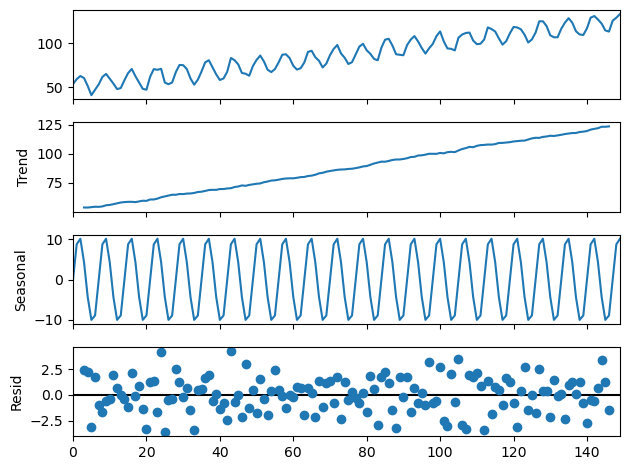

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
n = 150
dates = pd.date_range(start='2024-01-01', periods=n, freq='D')
data = 50 + np.arange(n) * 0.5 + 10 * np.sin(np.arange(n) * (2 * np.pi / 7)) + np.random.normal(0, 2, n)
ts = pd.Series(data, index=dates)

# Perform decomposition (additive model is typical for stable seasonality)
result_classical = seasonal_decompose(ts, model='additive', period=7) # Period is 7 for daily data with a weekly cycle

# Plot the results
result_classical.plot()
plt.show()

In [60]:
df

,realtime_start,realtime_end,date,value
0,2026-01-14,2026-01-14,1992-01-01,13130.0
1,2026-01-14,2026-01-14,1992-02-01,13276.0
2,2026-01-14,2026-01-14,1992-03-01,14135.0
3,2026-01-14,2026-01-14,1992-04-01,13858.0
4,2026-01-14,2026-01-14,1992-05-01,14854.0
...,...,...,...,...
401,2026-01-14,2026-01-14,2025-06-01,91755.0
402,2026-01-14,2026-01-14,2025-07-01,92574.0
403,2026-01-14,2026-01-14,2025-08-01,94539.0
404,2026-01-14,2026-01-14,2025-09-01,86585.0


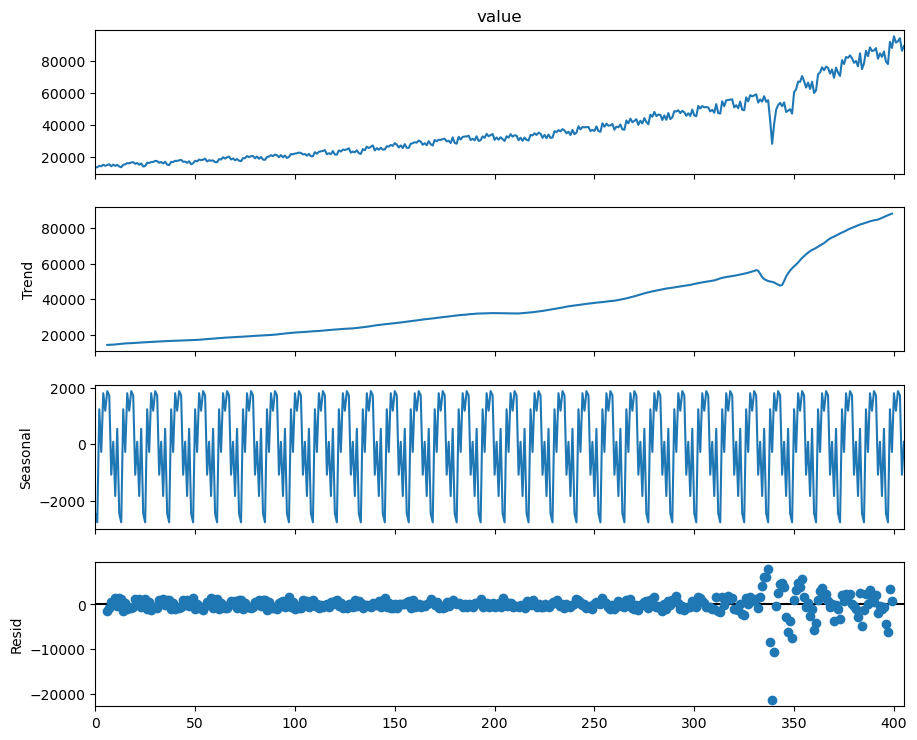

In [ ]:
df['index'] = pd.to_datetime(df['date'])
decomposition = seasonal_decompose(df['value'], model='additive', period=12) 

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

22:43:52 - cmdstanpy - INFO - Chain [1] start processing
22:43:52 - cmdstanpy - INFO - Chain [1] done processing


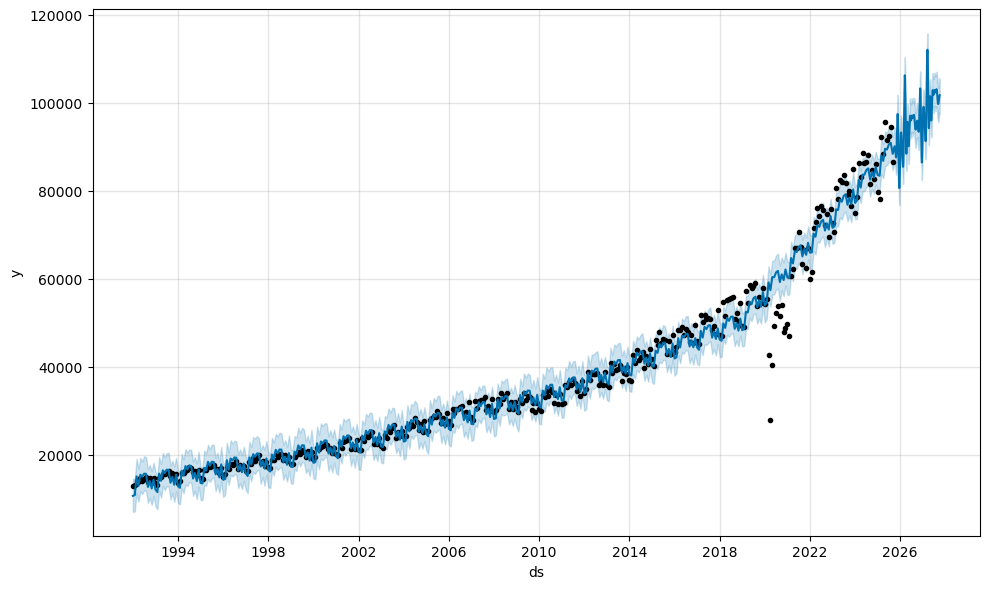

In [66]:
from prophet import Prophet
model = Prophet()
prophet_train_df = df.rename(columns={'date': 'ds', 'value': 'y'})
model.fit(prophet_train_df)
future = model.make_future_dataframe(periods=365*2)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()

In [47]:
print(df.to_markdown(index=False))

| realtime_start   | realtime_end   | date       |   value |
|:-----------------|:---------------|:-----------|--------:|
| 2026-01-14       | 2026-01-14     | 1992-01-01 |   13130 |
| 2026-01-14       | 2026-01-14     | 1992-02-01 |   13276 |
| 2026-01-14       | 2026-01-14     | 1992-03-01 |   14135 |
| 2026-01-14       | 2026-01-14     | 1992-04-01 |   13858 |
| 2026-01-14       | 2026-01-14     | 1992-05-01 |   14854 |
| 2026-01-14       | 2026-01-14     | 1992-06-01 |   14173 |
| 2026-01-14       | 2026-01-14     | 1992-07-01 |   14657 |
| 2026-01-14       | 2026-01-14     | 1992-08-01 |   15155 |
| 2026-01-14       | 2026-01-14     | 1992-09-01 |   13882 |
| 2026-01-14       | 2026-01-14     | 1992-10-01 |   14918 |
| 2026-01-14       | 2026-01-14     | 1992-11-01 |   14115 |
| 2026-01-14       | 2026-01-14     | 1992-12-01 |   14780 |
| 2026-01-14       | 2026-01-14     | 1993-01-01 |   13775 |
| 2026-01-14       | 2026-01-14     | 1993-02-01 |   13268 |
| 2026-01-14       | 202

In [41]:
print(type(df.to_markdown()))

<class 'str'>


In [43]:
import io

markdown_table = """
| Name       | Role          | Level |
|------------|---------------|-------|
| Alice      | Engineer      | Senior|
| Bob        | Designer      | Lead  |
| Charlie    | Product       | Junior|
"""

# 1. Strip whitespace and remove the "separator row" (the one with ---)
lines = [line.strip() for line in markdown_table.strip().split('\n') 
         if not all(c in '-| ' for c in line)]

# 2. Join back and use read_csv with the pipe separator
df = pd.read_csv(io.StringIO('\n'.join(lines)), sep='|', engine='python')

# 3. Drop any empty columns created by the leading/trailing pipes
df = df.dropna(axis=1, how='all') # Adjust slicing if needed
# Standard cleanup: strip column names and data
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

print(df)

      Name      Role   Level
0    Alice  Engineer  Senior
1      Bob  Designer    Lead
2  Charlie   Product  Junior
